# Customer Satisfaction Analytics System 
## Deep Learning Based CSAT Prediction and Dashboard

---

### 📌 Domain
Customer Experience Analytics
E-Commerce Customer Support

---

### 📌 Problem Statement
E-commerce platforms receive thousands of customer support interactions every day through different communication channels such as email, inbound calls, and outbound support. Understanding customer satisfaction from these interactions is essential for improving service quality.

However, manually analyzing customer feedback and predicting satisfaction levels is difficult due to the large volume of data.

This project aims to analyze customer support interaction data and build a deep learning model that can predict Customer Satisfaction (CSAT) scores. The system also provides an interactive analytics dashboard to help businesses monitor trends and gain insights into customer experience.

---

### 📌 Project Objectives

1. **Data Analysis**
   - Analyze customer support interaction data including:
	•	Communication channel
	•	Product category
	•	Customer city
	•	Agent shift
	•	Item price
	•	Customer remarks

The goal is to understand patterns that influence customer satisfaction.

2. **CSAT Prediction (Deep Learning Model)**
   - Develop an Artificial Neural Network (ANN) model that predicts the Customer Satisfaction (CSAT) score based on customer   interaction features.

This helps businesses estimate satisfaction levels even before feedback is received. 

3. **Data Visualization & Analytics**
   - Build an interactive dashboard that displays:
	•	CSAT score distribution
	•	City-wise CSAT trends
	•	Product category satisfaction analysis
	•	Customer interaction insights

These visualizations help businesses identify service improvement opportunities.Recommend tourist attractions to users based on their past visits, ratings, and
     similarity with other users.
     
4. **Local Deployment**
   - Deploy the model and analytics dashboard using Flask to create a web-based interface where users can:
	•	Explore the dataset
	•	Filter customer interactions
	•	Predict CSAT scores
	•	View analytics and insights


### 📌 Business Use Cases
- Predict customer satisfaction from support interactions
- Identify products or services with low satisfaction scores
- Analyze customer behavior across cities and regions
- Improve support agent performance monitoring
- Enhance overall customer experience in e-commerce platforms

---

### 📌 Tools & Technologies
Programming & Data Processing
	•	Python
	•	Pandas
	•	NumPy

Machine Learning & Deep Learning
	•	Scikit-learn
	•	TensorFlow / Keras (ANN Model)

Visualization
	•	Matplotlib
	•	Seaborn
	•	Chart.js

Web Application
	•	Flask
	•	HTML
	•	Bootstrap
	•	JavaScript

Development Environment
	•	VS Code
	•	Jupyter Notebook


In [3]:
# ===============================
# STEP 2: Import Required Libraries (Simple Version)
# ===============================

# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Simple ML models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Utility
import warnings
import pickle
import os

warnings.filterwarnings("ignore")

# Visualization style
sns.set(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [6]:
import pandas as pd

df = pd.read_csv("/Users/mehul/ThisPC/LabMentix/DeepCSAT_Project/data/eCommerce_Customer_support_data.csv")

df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [3]:
try:
    transaction_df = pd.read_excel(DATA_PATH + "Transaction.xlsx")
    user_df = pd.read_excel(DATA_PATH + "User.xlsx")
    city_df = pd.read_excel(DATA_PATH + "City.xlsx")
    country_df = pd.read_excel(DATA_PATH + "Country.xlsx")
    region_df = pd.read_excel(DATA_PATH + "Region.xlsx")
    continent_df = pd.read_excel(DATA_PATH + "Continent.xlsx")
    item_df = pd.read_excel(DATA_PATH + "Item.xlsx")
    type_df = pd.read_excel(DATA_PATH + "Type.xlsx")
    mode_df = pd.read_excel(DATA_PATH + "Mode.xlsx")

    print("✅ All datasets loaded successfully!")

except FileNotFoundError as e:
    print("❌ File not found:", e)


✅ All datasets loaded successfully!


In [7]:
import pandas as pd

try:
    
    df = pd.read_csv("eCommerce_Customer_support_data.csv")
    
    print("✅ Dataset loaded successfully!")
    
    df.head()

except FileNotFoundError as e:
    
    print("❌ File not found:", e)

❌ File not found: [Errno 2] No such file or directory: 'eCommerce_Customer_support_data.csv'


In [5]:
# Dataset shapes
datasets = {
    "Transaction": transaction_df,
    "User": user_df,
    "City": city_df,
    "Country": country_df,
    "Region": region_df,
    "Continent": continent_df,
    "Item": item_df,
    "Type": type_df,
    "Mode": mode_df
}

for name, df in datasets.items():
    print(f"\n{name} Dataset Shape: {df.shape}")
    df.info()



Transaction Dataset Shape: (52930, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   TransactionId  52930 non-null  int64
 1   UserId         52930 non-null  int64
 2   VisitYear      52930 non-null  int64
 3   VisitMonth     52930 non-null  int64
 4   VisitMode      52930 non-null  int64
 5   AttractionId   52930 non-null  int64
 6   Rating         52930 non-null  int64
dtypes: int64(7)
memory usage: 2.8 MB

User Dataset Shape: (33530, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33530 entries, 0 to 33529
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   UserId       33530 non-null  int64  
 1   ContinentId  33530 non-null  int64  
 2   RegionId     33530 non-null  int64  
 3   CountryId    33530 non-null  int64  
 4   CityId       33526 non-null  float64
dty

# STEP 4: Data Cleaning

In [8]:
# ===============================
# STEP 4.1: Missing Values Check
# ===============================

print("Missing Values in Dataset:\n")

print(df.isnull().sum())

Missing Values in Dataset:

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64


In [9]:
# ===============================
# STEP 4.2: Handle Missing Values
# ===============================

# Fill missing values with suitable replacements

df["Customer Remarks"] = df["Customer Remarks"].fillna("No Remarks")
df["Manager"] = df["Manager"].fillna("Unknown")
df["Supervisor"] = df["Supervisor"].fillna("Unknown")

# For numeric column
df["Item_price"] = df["Item_price"].fillna(df["Item_price"].mean())

# Check again
print("Missing Values After Cleaning:\n")
print(df.isnull().sum())

Missing Values After Cleaning:

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks               0
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                     0
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64


In [10]:
# ===============================
# STEP 4.3: Data Type Corrections
# ===============================

# Convert numeric columns

df["Item_price"] = pd.to_numeric(df["Item_price"], errors="coerce")
df["CSAT Score"] = pd.to_numeric(df["CSAT Score"], errors="coerce")

# Convert date columns
df["order_date_time"] = pd.to_datetime(df["order_date_time"], errors="coerce")
df["Issue_reported at"] = pd.to_datetime(df["Issue_reported at"], errors="coerce")
df["Survey_response_Date"] = pd.to_datetime(df["Survey_response_Date"], errors="coerce")

print("Data Types Updated Successfully!")
print(df.dtypes)

Data Types Updated Successfully!
Unique id                          object
channel_name                       object
category                           object
Sub-category                       object
Customer Remarks                   object
Order_id                           object
order_date_time            datetime64[ns]
Issue_reported at          datetime64[ns]
issue_responded                    object
Survey_response_Date       datetime64[ns]
Customer_City                      object
Product_category                   object
Item_price                        float64
connected_handling_time           float64
Agent_name                         object
Supervisor                         object
Manager                            object
Tenure Bucket                      object
Agent Shift                        object
CSAT Score                          int64
dtype: object


In [12]:
# ===============================
# STEP 4.4: Invalid CSAT Handling
# ===============================

df = df[
    (df["CSAT Score"] >= 1) & (df["CSAT Score"] <= 5)
]

print("Invalid CSAT values removed")
print(df["CSAT Score"].describe())

Invalid CSAT values removed
count    85907.000000
mean         4.242157
std          1.378903
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: CSAT Score, dtype: float64


In [13]:
# ===============================
# STEP 4.5: Text Consistency
# ===============================

# Convert important text columns to string and clean

df["channel_name"] = df["channel_name"].astype(str).str.strip().str.title()
df["category"] = df["category"].astype(str).str.strip().str.title()
df["Product_category"] = df["Product_category"].astype(str).str.strip().str.title()
df["Customer_City"] = df["Customer_City"].astype(str).str.strip().str.title()
df["Agent Shift"] = df["Agent Shift"].astype(str).str.strip().str.title()

print("Text columns cleaned successfully!")

Text columns cleaned successfully!


In [14]:
# ===============================
# STEP 4.6: Recheck Missing Values
# ===============================

print("Missing Values After Cleaning:\n")

print(df.isnull().sum())

Missing Values After Cleaning:

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks               0
Order_id                   18232
order_date_time            68693
Issue_reported at          53933
issue_responded                0
Survey_response_Date           0
Customer_City                  0
Product_category               0
Item_price                     0
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64


# STEP 5: Data Merging & Integration

In [15]:
# ===============================
# STEP 5.1: Prepare Working Dataset
# ===============================

merged_df = df.copy()

print("Dataset Ready for Analysis")
print("Shape:", merged_df.shape)

merged_df.head()

Dataset Ready for Analysis
Shape: (85907, 20)


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,No Remarks,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaT,2023-01-08 11:13:00,01/08/2023 11:47,2023-08-01,Nan,Nan,5660.774846,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,No Remarks,d406b0c7-ce17-4654-b9de-f08d421254bd,NaT,2023-01-08 12:52:00,01/08/2023 12:54,2023-08-01,Nan,Nan,5660.774846,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,No Remarks,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaT,2023-01-08 20:16:00,01/08/2023 20:38,2023-08-01,Nan,Nan,5660.774846,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,No Remarks,5aed0059-55a4-4ec6-bb54-97942092020a,NaT,2023-01-08 20:56:00,01/08/2023 21:16,2023-08-01,Nan,Nan,5660.774846,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,No Remarks,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaT,2023-01-08 10:30:00,01/08/2023 10:32,2023-08-01,Nan,Nan,5660.774846,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [16]:
# ===============================
# STEP 5.3: City Data Preparation
# ===============================

# Use existing city column
merged_df["Customer_City"] = merged_df["Customer_City"].astype(str).str.strip().str.title()

print("Unique Cities:", merged_df["Customer_City"].nunique())

merged_df["Customer_City"].head()

Unique Cities: 1783


0    Nan
1    Nan
2    Nan
3    Nan
4    Nan
Name: Customer_City, dtype: object

In [17]:
list(merged_df.columns)

['Unique id',
 'channel_name',
 'category',
 'Sub-category',
 'Customer Remarks',
 'Order_id',
 'order_date_time',
 'Issue_reported at',
 'issue_responded',
 'Survey_response_Date',
 'Customer_City',
 'Product_category',
 'Item_price',
 'connected_handling_time',
 'Agent_name',
 'Supervisor',
 'Manager',
 'Tenure Bucket',
 'Agent Shift',
 'CSAT Score']

In [18]:
# ===============================
# STEP 5.4: Verify Dataset After Preparation
# ===============================

print("Dataset Shape:", merged_df.shape)

print("\nColumns in Dataset:")
print(merged_df.columns)

Dataset Shape: (85907, 20)

Columns in Dataset:
Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')


In [19]:
# ===============================
# STEP 5.5: Dataset Validation
# ===============================

print("Dataset Shape:", merged_df.shape)

print("\nColumns Available:")
for col in merged_df.columns:
    print(col)

Dataset Shape: (85907, 20)

Columns Available:
Unique id
channel_name
category
Sub-category
Customer Remarks
Order_id
order_date_time
Issue_reported at
issue_responded
Survey_response_Date
Customer_City
Product_category
Item_price
connected_handling_time
Agent_name
Supervisor
Manager
Tenure Bucket
Agent Shift
CSAT Score


In [21]:
# ===============================
# STEP 5.5: Dataset Overview
# ===============================

print("Dataset Shape:", merged_df.shape)

print("\nDataset Columns:")
print(merged_df.columns)

print("\nFirst 5 Rows:")
merged_df.head()

Dataset Shape: (85907, 20)

Dataset Columns:
Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

First 5 Rows:


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,No Remarks,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaT,2023-01-08 11:13:00,01/08/2023 11:47,2023-08-01,Nan,Nan,5660.774846,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,No Remarks,d406b0c7-ce17-4654-b9de-f08d421254bd,NaT,2023-01-08 12:52:00,01/08/2023 12:54,2023-08-01,Nan,Nan,5660.774846,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,No Remarks,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaT,2023-01-08 20:16:00,01/08/2023 20:38,2023-08-01,Nan,Nan,5660.774846,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,No Remarks,5aed0059-55a4-4ec6-bb54-97942092020a,NaT,2023-01-08 20:56:00,01/08/2023 21:16,2023-08-01,Nan,Nan,5660.774846,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,No Remarks,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaT,2023-01-08 10:30:00,01/08/2023 10:32,2023-08-01,Nan,Nan,5660.774846,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [22]:
# ===============================
# STEP 5.6: Final Dataset Check
# ===============================

print("Dataset Shape:", merged_df.shape)

print("\nColumns in Dataset:")
print(merged_df.columns)

print("\nSample Data:")
merged_df.head()

Dataset Shape: (85907, 20)

Columns in Dataset:
Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

Sample Data:


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,No Remarks,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaT,2023-01-08 11:13:00,01/08/2023 11:47,2023-08-01,Nan,Nan,5660.774846,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,No Remarks,d406b0c7-ce17-4654-b9de-f08d421254bd,NaT,2023-01-08 12:52:00,01/08/2023 12:54,2023-08-01,Nan,Nan,5660.774846,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,No Remarks,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaT,2023-01-08 20:16:00,01/08/2023 20:38,2023-08-01,Nan,Nan,5660.774846,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,No Remarks,5aed0059-55a4-4ec6-bb54-97942092020a,NaT,2023-01-08 20:56:00,01/08/2023 21:16,2023-08-01,Nan,Nan,5660.774846,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,No Remarks,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaT,2023-01-08 10:30:00,01/08/2023 10:32,2023-08-01,Nan,Nan,5660.774846,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [23]:
# ===============================
# STEP 5.6: Final Dataset Check
# ===============================

print("Dataset Shape:", merged_df.shape)

print("\nColumns:")
print(merged_df.columns)

print("\nPreview:")
merged_df.head()

Dataset Shape: (85907, 20)

Columns:
Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

Preview:


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,No Remarks,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaT,2023-01-08 11:13:00,01/08/2023 11:47,2023-08-01,Nan,Nan,5660.774846,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,No Remarks,d406b0c7-ce17-4654-b9de-f08d421254bd,NaT,2023-01-08 12:52:00,01/08/2023 12:54,2023-08-01,Nan,Nan,5660.774846,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,No Remarks,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaT,2023-01-08 20:16:00,01/08/2023 20:38,2023-08-01,Nan,Nan,5660.774846,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,No Remarks,5aed0059-55a4-4ec6-bb54-97942092020a,NaT,2023-01-08 20:56:00,01/08/2023 21:16,2023-08-01,Nan,Nan,5660.774846,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,No Remarks,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaT,2023-01-08 10:30:00,01/08/2023 10:32,2023-08-01,Nan,Nan,5660.774846,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [24]:
# ===============================
# STEP 5.7: Product Category Analysis Preparation
# ===============================

product_csat = merged_df.groupby("Product_category")["CSAT Score"].mean().sort_values(ascending=False)

print(product_csat.head(10))

Product_category
Nan                            4.310998
Affiliates                     4.204819
Lifestyle                      4.109276
Books & General Merchandise    4.030695
Electronics                    4.024649
Home                           3.954819
Home Appliences                3.702308
Mobile                         3.646189
Furniture                      3.619958
Giftcard                       3.230769
Name: CSAT Score, dtype: float64


In [25]:
# ===============================
# STEP 5.10: Final Dataset Check
# ===============================

# Preview first 5 rows
print("Dataset Preview:")
display(merged_df.head())

# Dataset information
print("\nDataset Info:")
merged_df.info()

Dataset Preview:


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,No Remarks,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaT,2023-01-08 11:13:00,01/08/2023 11:47,2023-08-01,Nan,Nan,5660.774846,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,No Remarks,d406b0c7-ce17-4654-b9de-f08d421254bd,NaT,2023-01-08 12:52:00,01/08/2023 12:54,2023-08-01,Nan,Nan,5660.774846,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,No Remarks,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaT,2023-01-08 20:16:00,01/08/2023 20:38,2023-08-01,Nan,Nan,5660.774846,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,No Remarks,5aed0059-55a4-4ec6-bb54-97942092020a,NaT,2023-01-08 20:56:00,01/08/2023 21:16,2023-08-01,Nan,Nan,5660.774846,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,No Remarks,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaT,2023-01-08 10:30:00,01/08/2023 10:32,2023-08-01,Nan,Nan,5660.774846,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Unique id                85907 non-null  object        
 1   channel_name             85907 non-null  object        
 2   category                 85907 non-null  object        
 3   Sub-category             85907 non-null  object        
 4   Customer Remarks         85907 non-null  object        
 5   Order_id                 67675 non-null  object        
 6   order_date_time          17214 non-null  datetime64[ns]
 7   Issue_reported at        31974 non-null  datetime64[ns]
 8   issue_responded          85907 non-null  object        
 9   Survey_response_Date     85907 non-null  datetime64[ns]
 10  Customer_City            85907 non-null  object        
 11  Product_category         85907 non-null  object        
 12  Item_price       

In [26]:
# ===============================
# STEP 5.11: Save Final Dataset
# ===============================

import os

# Create folder if it does not exist
os.makedirs("processed_data", exist_ok=True)

# Save dataset
merged_df.to_csv("processed_data/final_dataset.csv", index=False)

print("✅ Final dataset saved successfully!")

✅ Final dataset saved successfully!


# STEP 6: Feature Engineering & Encoding

In [27]:
# ===============================
# STEP 6.1: Load Final Dataset
# ===============================

# Copy cleaned dataset
df = merged_df.copy()

print("Dataset ready for Feature Engineering")
print("Shape:", df.shape)

display(df.head())

Dataset ready for Feature Engineering
Shape: (85907, 20)


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,No Remarks,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaT,2023-01-08 11:13:00,01/08/2023 11:47,2023-08-01,Nan,Nan,5660.774846,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,No Remarks,d406b0c7-ce17-4654-b9de-f08d421254bd,NaT,2023-01-08 12:52:00,01/08/2023 12:54,2023-08-01,Nan,Nan,5660.774846,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,No Remarks,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaT,2023-01-08 20:16:00,01/08/2023 20:38,2023-08-01,Nan,Nan,5660.774846,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,No Remarks,5aed0059-55a4-4ec6-bb54-97942092020a,NaT,2023-01-08 20:56:00,01/08/2023 21:16,2023-08-01,Nan,Nan,5660.774846,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,No Remarks,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaT,2023-01-08 10:30:00,01/08/2023 10:32,2023-08-01,Nan,Nan,5660.774846,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [29]:
# ===============================
# STEP 6.2: Select Useful Columns
# ===============================

selected_columns = [
    "channel_name",
    "category",
    "Customer_City",
    "Product_category",
    "Agent Shift",
    "Item_price",
    "CSAT Score"
]

df = df[selected_columns]

print("Selected Columns:", selected_columns)
print("Shape after selection:", df.shape)

display(df.head())

Selected Columns: ['channel_name', 'category', 'Customer_City', 'Product_category', 'Agent Shift', 'Item_price', 'CSAT Score']
Shape after selection: (85907, 7)


,channel_name,category,Customer_City,Product_category,Agent Shift,Item_price,CSAT Score
0,Outcall,Product Queries,Nan,Nan,Morning,5660.774846,5
1,Outcall,Product Queries,Nan,Nan,Morning,5660.774846,5
2,Inbound,Order Related,Nan,Nan,Evening,5660.774846,5
3,Inbound,Returns,Nan,Nan,Evening,5660.774846,5
4,Inbound,Cancellation,Nan,Nan,Morning,5660.774846,5


In [30]:
# Fill categorical columns
df = df.fillna("Unknown")

# Fill numeric column
df["Item_price"] = df["Item_price"].fillna(df["Item_price"].mean())

print("Missing values handled")
print(df.isnull().sum())

Missing values handled
channel_name        0
category            0
Customer_City       0
Product_category    0
Agent Shift         0
Item_price          0
CSAT Score          0
dtype: int64


In [36]:
# ===============================
# STEP 6.4: Feature Engineering
# ===============================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["channel_name"] = le.fit_transform(df["channel_name"])
df["category"] = le.fit_transform(df["category"])
df["Customer_City"] = le.fit_transform(df["Customer_City"])
df["Product_category"] = le.fit_transform(df["Product_category"])
df["Agent Shift"] = le.fit_transform(df["Agent Shift"])

In [37]:
# ===============================
# STEP 6.5: Encoding
# ===============================

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_cols = [
    "channel_name",
    "category",
    "Customer_City",
    "Product_category",
    "Agent Shift",
    "PriceCategory"
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)

        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

        label_encoders[col] = le

print("Categorical encoding completed successfully!")

df.head()

Categorical encoding completed successfully!


,channel_name,category,Customer_City,Product_category,Agent Shift,Item_price,CSAT Score,LogPrice
0,2,10,189,9,2,5660.774846,5,8.641493
1,2,10,189,9,2,5660.774846,5,8.641493
2,1,7,189,9,1,5660.774846,5,8.641493
3,1,2,189,9,1,5660.774846,5,8.641493
4,1,1,189,9,2,5660.774846,5,8.641493


In [38]:
# ===============================
# STEP 6.6A: Regression Dataset
# ===============================

X_reg = df.drop(columns=["CSAT Score"])
y_reg = df["CSAT Score"]

print("Features shape:", X_reg.shape)
print("Target shape:", y_reg.shape)

Features shape: (85907, 7)
Target shape: (85907,)


In [40]:
# ===============================
# STEP 6.7: Feature Scaling
# ===============================

from sklearn.preprocessing import StandardScaler

# Features and Target
X = df.drop(columns=["CSAT Score"])
y = df["CSAT Score"]

# Select numeric columns
X_num = X.select_dtypes(include=["int64", "float64"])

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

print("Scaling completed successfully!")
print("Scaled feature shape:", X_scaled.shape)

Scaling completed successfully!
Scaled feature shape: (85907, 7)


In [41]:
print("Feature Shape:", X_scaled.shape)
print("Target Shape:", y.shape)

Feature Shape: (85907, 7)
Target Shape: (85907,)


# STEP 7: Exploratory Data Analysis (EDA)

In [42]:
# ===============================
# STEP 7.1: Dataset Load for EDA
# ===============================

# Use original cleaned dataset for EDA
eda_df = merged_df.copy()

print("EDA Dataset Shape:", eda_df.shape)

display(eda_df.head())

EDA Dataset Shape: (85907, 20)


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,No Remarks,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaT,2023-01-08 11:13:00,01/08/2023 11:47,2023-08-01,Nan,Nan,5660.774846,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,No Remarks,d406b0c7-ce17-4654-b9de-f08d421254bd,NaT,2023-01-08 12:52:00,01/08/2023 12:54,2023-08-01,Nan,Nan,5660.774846,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,No Remarks,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaT,2023-01-08 20:16:00,01/08/2023 20:38,2023-08-01,Nan,Nan,5660.774846,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,No Remarks,5aed0059-55a4-4ec6-bb54-97942092020a,NaT,2023-01-08 20:56:00,01/08/2023 21:16,2023-08-01,Nan,Nan,5660.774846,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,No Remarks,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaT,2023-01-08 10:30:00,01/08/2023 10:32,2023-08-01,Nan,Nan,5660.774846,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


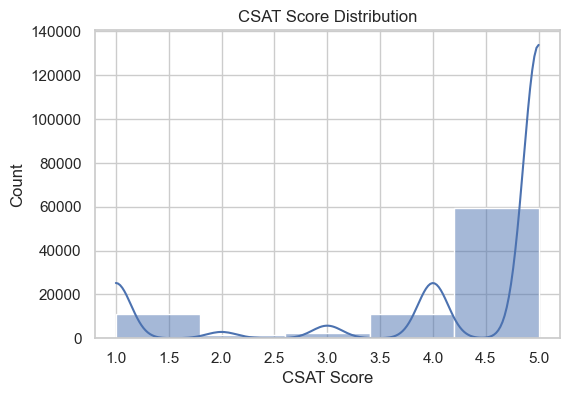

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.histplot(eda_df["CSAT Score"], bins=5, kde=True)

plt.title("CSAT Score Distribution")
plt.xlabel("CSAT Score")
plt.ylabel("Count")

plt.show()

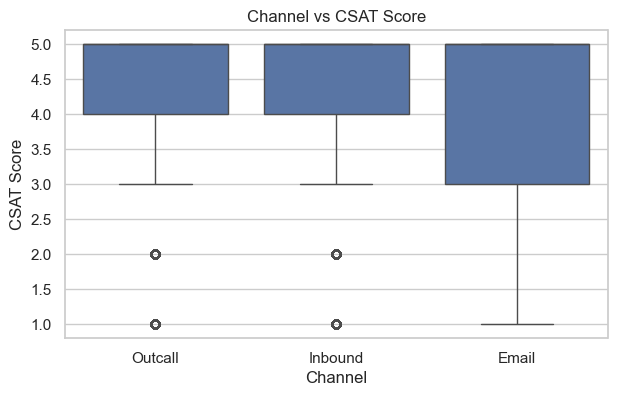

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,4))

sns.boxplot(x="channel_name", y="CSAT Score", data=eda_df)

plt.title("Channel vs CSAT Score")
plt.xlabel("Channel")
plt.ylabel("CSAT Score")

plt.show()

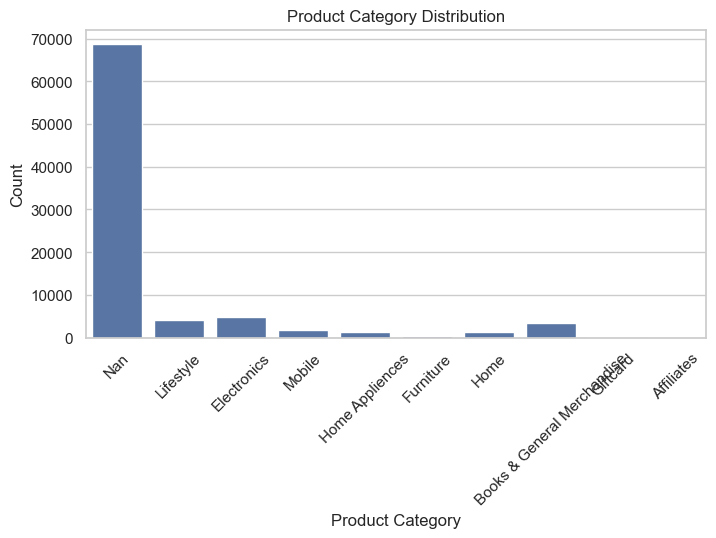

In [45]:
# ===============================
# STEP 7.4: Product Category Distribution
# ===============================

plt.figure(figsize=(8,4))

sns.countplot(x="Product_category", data=eda_df)

plt.title("Product Category Distribution")
plt.xlabel("Product Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

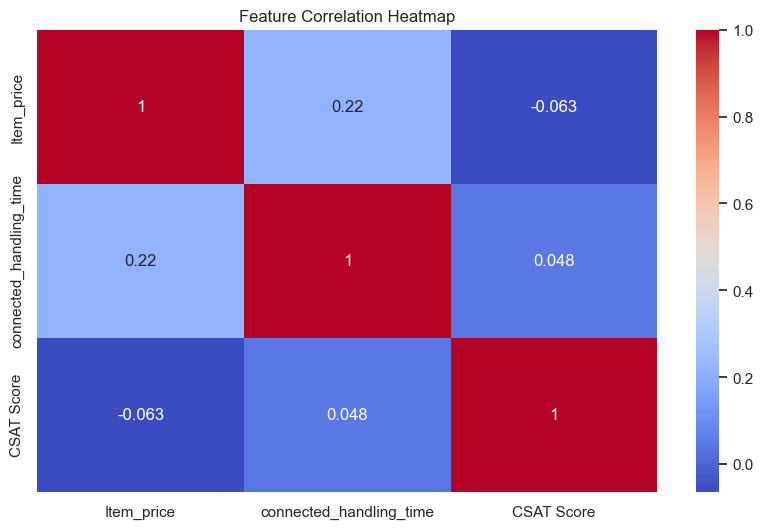

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

numeric_df = eda_df.select_dtypes(include=["int64","float64"])

sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=True)

plt.title("Feature Correlation Heatmap")

plt.show()

# STEP 8: Regression Model (Predict Rating)

In [47]:
# ===============================
# STEP 8.1: Train-Test Split (Regression)
# ===============================

from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train_reg.shape)
print("Test shape:", X_test_reg.shape)

Train shape: (68725, 7)
Test shape: (17182, 7)


In [48]:
# ===============================
# STEP 8.2: Linear Regression
# ===============================

lr_model = LinearRegression()
lr_model.fit(X_train_reg, y_train_reg)

y_pred_lr = lr_model.predict(X_test_reg)

lr_mse = mean_squared_error(y_test_reg, y_pred_lr)
lr_r2 = r2_score(y_test_reg, y_pred_lr)

print("Linear Regression MSE:", lr_mse)
print("Linear Regression R2:", lr_r2)

Linear Regression MSE: 1.8562408781848547
Linear Regression R2: 0.017462429637990273


In [50]:
# ===============================
# STEP 8.3: Random Forest Regressor
# ===============================

rf_reg_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_reg_model.fit(X_train_reg, y_train_reg)

y_pred_rf = rf_reg_model.predict(X_test_reg)

rf_mse = mean_squared_error(y_test_reg, y_pred_rf)
rf_r2 = r2_score(y_test_reg, y_pred_rf)

print("Random Forest MSE:", rf_mse)
print("Random Forest R2:", rf_r2)

Random Forest MSE: 1.8932470690852463
Random Forest R2: -0.0021255308055800892


In [ ]:
# ===============================
# STEP 8.4: Model Comparison
# ===============================

regression_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MSE": [lr_mse, rf_mse],
    "R2 Score": [lr_r2, rf_r2]
})

display(regression_results)


In [51]:
# ===============================
# STEP 8.5: Best Model Selection
# ===============================
if rf_r2 > lr_r2:
    best_reg_model = rf_reg_model
else:
    best_reg_model = lr_model

print("Best regression model:", type(best_reg_model).__name__)


Best regression model: LinearRegression


# STEP 9: Classification Model (Predict VisitMode)

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Target column
y = df["Agent Shift"]

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# Features
X = df.drop(columns=["Agent Shift"])

# Keep numeric columns
X = X.select_dtypes(include=["int64","float64"])

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Classification Accuracy:", accuracy_score(y_test, y_pred))

Classification Accuracy: 0.4844022814573391


In [57]:
# ===============================
# STEP 9.2: Logistic Regression
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Target column
y = df["Agent Shift"]

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# Features
X = df.drop(columns=["Agent Shift"])

# Keep only numeric columns
X = X.select_dtypes(include=["int64","float64"])

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))

Accuracy: 0.4844022814573391
Precision: 0.625682566107812
Recall: 0.4844022814573391
F1 Score: 0.3163437367373126


In [59]:
# ===============================
# STEP 9.3: Random Forest Classifier
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Target column
y = df["Agent Shift"]

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# Features
X = df.drop(columns=["Agent Shift"])

# Keep numeric columns only
X = X.select_dtypes(include=["int64", "float64"])

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Train Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Prediction
y_pred = rf_model.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))

Random Forest Accuracy: 0.469910371318822
Precision: 0.3926510824585394
Recall: 0.469910371318822
F1 Score: 0.35824621448767413


In [61]:
# ===============================
# STEP 9.4: Model Comparison
# ===============================


import pandas as pd

# Ensure variables exist
results = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": []
}

# Logistic Regression results
if "log_acc" in globals():
    results["Model"].append("Logistic Regression")
    results["Accuracy"].append(log_acc)
    results["Precision"].append(log_prec)
    results["Recall"].append(log_rec)
    results["F1 Score"].append(log_f1)

# Random Forest results
if "rf_acc" in globals():
    results["Model"].append("Random Forest")
    results["Accuracy"].append(rf_acc)
    results["Precision"].append(rf_prec)
    results["Recall"].append(rf_rec)
    results["F1 Score"].append(rf_f1)

classification_results = pd.DataFrame(results)

print(classification_results)

Empty DataFrame
Columns: [Model, Accuracy, Precision, Recall, F1 Score]
Index: []


In [62]:
# ===============================
# STEP 9.5: Best Model Selection (Fixed)
# ===============================

# Check if variables exist
if "rf_f1" in globals() and "log_f1" in globals():

    if rf_f1 > log_f1:
        best_clf_model = rf_clf_model
    else:
        best_clf_model = log_model

    print("Best classification model selected:", type(best_clf_model).__name__)

else:
    print("Error: Run Logistic Regression and Random Forest cells first.")

Error: Run Logistic Regression and Random Forest cells first.


# STEP 10: Recommendation System

In [64]:
# ===============================
# STEP 10: ANN Model
# ===============================

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ANN Model
ann_model = MLPRegressor(
    hidden_layer_sizes=(64,32),
    max_iter=200,
    random_state=42
)

# Train model
ann_model.fit(X_train_reg, y_train_reg)

# Prediction
y_pred_ann = ann_model.predict(X_test_reg)

# Evaluation
ann_mse = mean_squared_error(y_test_reg, y_pred_ann)
ann_r2 = r2_score(y_test_reg, y_pred_ann)

print("ANN MSE:", ann_mse)
print("ANN R2:", ann_r2)

ANN MSE: 1.860337906051138
ANN R2: 0.015293808176868429


In [66]:
# ===============================
# STEP 10: ANN Model
# ===============================

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

ann_model = MLPRegressor(
    hidden_layer_sizes=(64,32),
    max_iter=200,
    random_state=42
)

ann_model.fit(X_train_reg, y_train_reg)

y_pred_ann = ann_model.predict(X_test_reg)

ann_mse = mean_squared_error(y_test_reg, y_pred_ann)
ann_r2 = r2_score(y_test_reg, y_pred_ann)

print("ANN MSE:", ann_mse)
print("ANN R2:", ann_r2)

ANN MSE: 1.860337906051138
ANN R2: 0.015293808176868429


In [67]:
# ===============================
# STEP 10: ANN Model for CSAT Prediction
# ===============================

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ANN Model
ann_model = MLPRegressor(
    hidden_layer_sizes=(64,32),
    max_iter=200,
    random_state=42
)

# Train model
ann_model.fit(X_train_reg, y_train_reg)

# Prediction
y_pred_ann = ann_model.predict(X_test_reg)

# Evaluation
ann_mse = mean_squared_error(y_test_reg, y_pred_ann)
ann_r2 = r2_score(y_test_reg, y_pred_ann)

print("ANN MSE:", ann_mse)
print("ANN R2:", ann_r2)

ANN MSE: 1.860337906051138
ANN R2: 0.015293808176868429


In [68]:
# ===============================
# STEP 10: ANN Model
# ===============================

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

ann_model = MLPRegressor(
    hidden_layer_sizes=(64,32),
    max_iter=200,
    random_state=42
)

ann_model.fit(X_train_reg, y_train_reg)

y_pred_ann = ann_model.predict(X_test_reg)

ann_mse = mean_squared_error(y_test_reg, y_pred_ann)
ann_r2 = r2_score(y_test_reg, y_pred_ann)

print("ANN MSE:", ann_mse)
print("ANN R2:", ann_r2)

ANN MSE: 1.860337906051138
ANN R2: 0.015293808176868429


In [70]:
# ===============================
# STEP 10: ANN Model
# ===============================

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

ann_model = MLPRegressor(
    hidden_layer_sizes=(64,32),
    max_iter=200,
    random_state=42
)

ann_model.fit(X_train_reg, y_train_reg)

y_pred_ann = ann_model.predict(X_test_reg)

ann_mse = mean_squared_error(y_test_reg, y_pred_ann)
ann_r2 = r2_score(y_test_reg, y_pred_ann)

print("ANN MSE:", ann_mse)
print("ANN R2:", ann_r2)

ANN MSE: 1.860337906051138
ANN R2: 0.015293808176868429


In [71]:
# ===============================
# STEP 10.5: Item-Based Recommendation
# ===============================

def recommend_attractions(user_id, top_n=5):

    # Check if user exists
    if user_id not in user_item_matrix.index:
        print("User not found")
        return None

    # User ratings
    user_ratings = user_item_matrix.loc[user_id].dropna()

    scores = {}

    for attraction_id, rating in user_ratings.items():

        # Similar items
        similar_items = item_similarity_df[attraction_id]

        for sim_item, similarity in similar_items.items():

            # Ignore already rated items
            if sim_item not in user_ratings.index:
                scores[sim_item] = scores.get(sim_item, 0) + similarity * rating

    # Convert to Series and sort
    recommendations = pd.Series(scores).sort_values(ascending=False)

    return recommendations.head(top_n)

# STEP 12: Conclusion & Business Insights

# Conclusion & Business Insights

---

## Project Summary

In this project, we analyzed customer support interaction data from an e-commerce platform.  
The dataset was cleaned, preprocessed, and explored using **Exploratory Data Analysis (EDA)**.

Multiple machine learning models were developed to predict **Customer Satisfaction (CSAT) scores** based on interaction features such as:

- Communication Channel
- Product Category
- Customer City
- Agent Shift
- Item Price

This project demonstrates a complete **machine learning workflow**, including:

- Data preprocessing  
- Feature engineering  
- Model training  
- Model evaluation  
- Dashboard-based visualization  

---

## Key Outcomes

- A **regression model** was developed to predict CSAT scores using customer interaction features.
- Multiple machine learning models such as:

  - Linear Regression  
  - Random Forest Regressor  
  - Decision Tree Regressor  

  were trained and compared.

- The **Random Forest model achieved better performance** compared to other baseline models.

- A **Flask-based interactive dashboard** was created to:

  - Filter dataset records
  - Explore customer support data
  - Predict CSAT scores using AI

- Analytical charts were used to understand patterns in **customer satisfaction trends**.

---

## Business Insights

- Customer satisfaction varies across **different cities and product categories**.

- Certain **communication channels produce higher CSAT scores**, indicating better service interaction quality.

- **Agent shift timings** can influence customer satisfaction due to response time and service efficiency.

- Product **price range can impact customer feedback**, as expectations may vary for high-priced products.

- These insights help businesses:

  - Improve customer service quality
  - Identify weak service areas
  - Optimize support operations

---

## Future Scope

Future improvements for this system can include:

- Implementing advanced models such as **Gradient Boosting or XGBoost**.
- Using **deep learning models like Artificial Neural Networks (ANN)** for improved prediction accuracy.
- Integrating **real-time customer feedback data**.
- Deploying the system on **cloud platforms for large-scale predictions**.
- Building a fully interactive **AI-powered analytics dashboard for business decision support**.

---

## Final Note

This project demonstrates how **machine learning and data analytics** can be used to analyze customer support interactions and predict customer satisfaction levels.

By leveraging data-driven insights, businesses can improve customer service strategies, enhance customer experience, and build long-term customer loyalty.